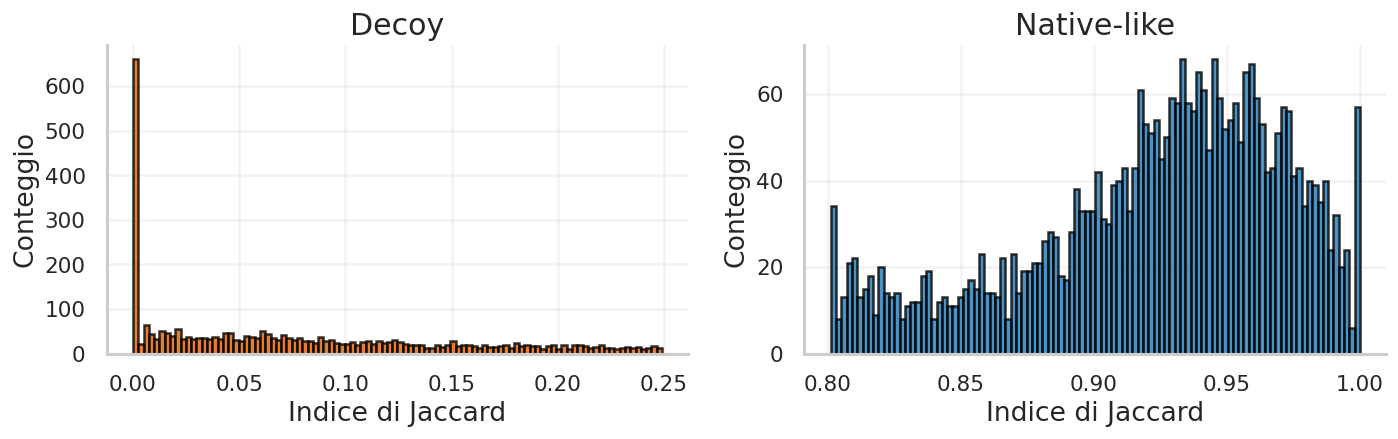

In [6]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="deep",
    font_scale=1.0,
 )
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

json_paths = {
    "decoys": Path("input_files/Jac_idx_decoy.json"),
    "native_like": Path("input_files/Jac_idx_native_like.json"),
}

with json_paths["decoys"].open("r", encoding="utf-8") as handle:
    decoy_values = json.load(handle)

with json_paths["native_like"].open("r", encoding="utf-8") as handle:
    native_like_values = json.load(handle)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(decoy_values, bins=100, color="#d95f02", alpha=0.8, edgecolor="black")
axes[0].set_title("Decoy")
axes[0].set_xlabel("Indice di Jaccard")
axes[0].set_ylabel("Conteggio")
axes[0].grid(alpha=0.25)

axes[1].hist(native_like_values, bins=100, color="#1f77b4", alpha=0.8, edgecolor="black")
axes[1].set_title("Native-like")
axes[1].set_xlabel("Indice di Jaccard")
axes[1].set_ylabel("Conteggio")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')
nativelike_df = pd.read_csv('output_files/nativelike/nativelike.csv')
nativelike_j_index_df = pd.read_csv('output_files/nativelike/nativelike_j_index.csv')

nativelike_prefixes = set(nativelike_j_index_df['complex name'].astype(str).str[:4])

N_RINGS = 10
RDF_DETECTOR_PREFIXES = ('physical_ring', 'zernike_ring', 'roughness_ring')
RDF_COL_PATTERNS = (
    'physical_ring{rid}_mean',
    'physical_ring{rid}_uncertainty',
    'zernike_ring{rid}_mean',
    'zernike_ring{rid}_uncertainty',
    'roughness_ring{rid}',
)


def _standardize_complex_name(df, column='complex_name'):
    df = df.copy()
    if column in df.columns:
        df[column] = df[column].astype(str).str[:4]
    return df


def _filter_by_prefixes(df, prefixes, column='complex_name'):
    df = df.copy()
    if column not in df.columns:
        return df
    return df[df[column].astype(str).str[:4].isin(prefixes)].copy()


def _build_ring_columns(df, patterns, n_rings=N_RINGS):
    ring_cols = {}
    for rid in range(1, n_rings + 1):
        cols = []
        for pattern in patterns:
            col = pattern.format(rid=rid)
            if col in df.columns:
                cols.append(col)
        ring_cols[rid] = cols
    return ring_cols


def _ring_has_value(row, cols):
    if not cols:
        return False
    vals = pd.to_numeric(row[cols], errors='coerce').to_numpy(dtype=float)
    return np.isfinite(vals).any()


def truncate_rdf_and_adjust_radius(df, radius_col='radius', n_rings=N_RINGS):
    df = df.copy()
    if radius_col not in df.columns:
        raise ValueError(f"Missing '{radius_col}' column")

    detector_patterns = tuple(f'{prefix}' + '{rid}_mean' if prefix != 'roughness_ring' else f'{prefix}' + '{rid}' for prefix in RDF_DETECTOR_PREFIXES)
    detector_cols = _build_ring_columns(df, detector_patterns, n_rings=n_rings)
    rdf_cols = _build_ring_columns(df, RDF_COL_PATTERNS, n_rings=n_rings)

    new_radius = pd.to_numeric(df[radius_col], errors='coerce').copy()

    for idx in df.index:
        row = df.loc[idx]
        has_values = {rid: _ring_has_value(row, detector_cols[rid]) for rid in range(1, n_rings + 1)}

        first_valid = next((rid for rid in range(1, n_rings + 1) if has_values[rid]), None)
        if first_valid is None:
            for rid in range(1, n_rings + 1):
                for col in rdf_cols[rid]:
                    df.at[idx, col] = np.nan
                ring_col = f'ring{rid}_mean_A'
                if ring_col in df.columns:
                    df.at[idx, ring_col] = np.nan
            new_radius.at[idx] = np.nan
            continue

        last_valid = first_valid
        for rid in range(first_valid + 1, n_rings + 1):
            if has_values[rid]:
                last_valid = rid
            else:
                break

        for rid in range(1, n_rings + 1):
            keep_ring = first_valid <= rid <= last_valid
            if not keep_ring:
                for col in rdf_cols[rid]:
                    df.at[idx, col] = np.nan

        original_radius = pd.to_numeric(pd.Series([row[radius_col]]), errors='coerce').iloc[0]
        if np.isfinite(original_radius) and original_radius > 0:
            new_radius.at[idx] = float(original_radius) * float(last_valid) / float(n_rings)
        else:
            new_radius.at[idx] = np.nan

        for rid in range(1, n_rings + 1):
            ring_col = f'ring{rid}_mean_A'
            if ring_col not in df.columns:
                continue
            keep_ring = first_valid <= rid <= last_valid
            if keep_ring and np.isfinite(original_radius) and original_radius > 0:
                df.at[idx, ring_col] = float(original_radius) * (rid - 0.5) / float(n_rings)
            else:
                df.at[idx, ring_col] = np.nan

    df[radius_col] = new_radius
    return df


def build_binned_real_rdf_profile(subset_df, metric_cols, radius_col='radius', bin_width=2.0, max_x=50.0):
    bin_edges = np.arange(0.0, max_x + bin_width, bin_width)
    bin_ids = list(range(len(bin_edges) - 1))
    per_bin_values = {bid: [] for bid in bin_ids}

    for _, row in subset_df.iterrows():
        radius_value = pd.to_numeric(pd.Series([row[radius_col]]), errors='coerce').iloc[0]
        if not np.isfinite(radius_value) or radius_value <= 0:
            continue

        for rid, metric_col in enumerate(metric_cols, start=1):
            if metric_col not in subset_df.columns:
                continue
            value = pd.to_numeric(pd.Series([row[metric_col]]), errors='coerce').iloc[0]
            if not np.isfinite(value):
                continue
            x_position = (rid - 0.5) * float(radius_value) / float(N_RINGS)
            if not np.isfinite(x_position) or x_position > max_x:
                continue
            bin_index = int(np.floor(x_position / bin_width))
            bin_index = min(bin_index, len(bin_ids) - 1)
            per_bin_values[bin_index].append(float(value))

    bin_centers = bin_edges[:-1] + bin_width / 2.0
    x_values = []
    y_values = []
    for bid, center in zip(bin_ids, bin_centers):
        values = per_bin_values[bid]
        if not values:
            continue
        x_values.append(float(center))
        y_values.append(float(np.mean(values)))

    return np.asarray(x_values, dtype=float), np.asarray(y_values, dtype=float)


def add_ring_mean_columns(df, radius_col='radius', n_rings=N_RINGS):
    for ring_id in range(1, n_rings + 1):
        df[f'ring{ring_id}_mean_A'] = pd.to_numeric(df[radius_col], errors='coerce') * (ring_id - 0.5) / n_rings
    return df


native_df = _standardize_complex_name(native_df)
decoys_df = _standardize_complex_name(decoys_df)
all_native_df = _standardize_complex_name(all_native_df)
nativelike_df = _filter_by_prefixes(nativelike_df, nativelike_prefixes)
nativelike_df = _standardize_complex_name(nativelike_df)

decoys2_df = decoys_df.copy()
common_complexes = sorted(set(decoys2_df['complex_name']).intersection(nativelike_df['complex_name']))
decoys2_df = decoys2_df[decoys2_df['complex_name'].isin(common_complexes)].copy()
nativelike_df = nativelike_df[nativelike_df['complex_name'].isin(common_complexes)].copy()

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)
nativelike_df = add_ring_mean_columns(nativelike_df)
decoys2_df = add_ring_mean_columns(decoys2_df)

#native_df = truncate_rdf_and_adjust_radius(native_df)
#decoys_df = truncate_rdf_and_adjust_radius(decoys_df)
#all_native_df = truncate_rdf_and_adjust_radius(all_native_df)
#nativelike_df = truncate_rdf_and_adjust_radius(nativelike_df)
#decoys2_df = truncate_rdf_and_adjust_radius(decoys2_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['dataset_label'] = 'decoy'

nativelike_labeled = nativelike_df.copy()
nativelike_labeled['dataset_label'] = 'nativelike'

decoys2_labeled = decoys2_df.copy()
decoys2_labeled['dataset_label'] = 'decoy2'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)
tot_nativelike_df = pd.concat([nativelike_labeled, decoys2_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('nativelike_df:', nativelike_df.shape)
print('decoys2_df:', decoys2_df.shape)
print('tot_df:', tot_df.shape)
print('tot_nativelike_df:', tot_nativelike_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
nativelike_df: (2665, 73)
decoys2_df: (2665, 73)
tot_df: (6268, 74)
tot_nativelike_df: (5330, 74)


/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

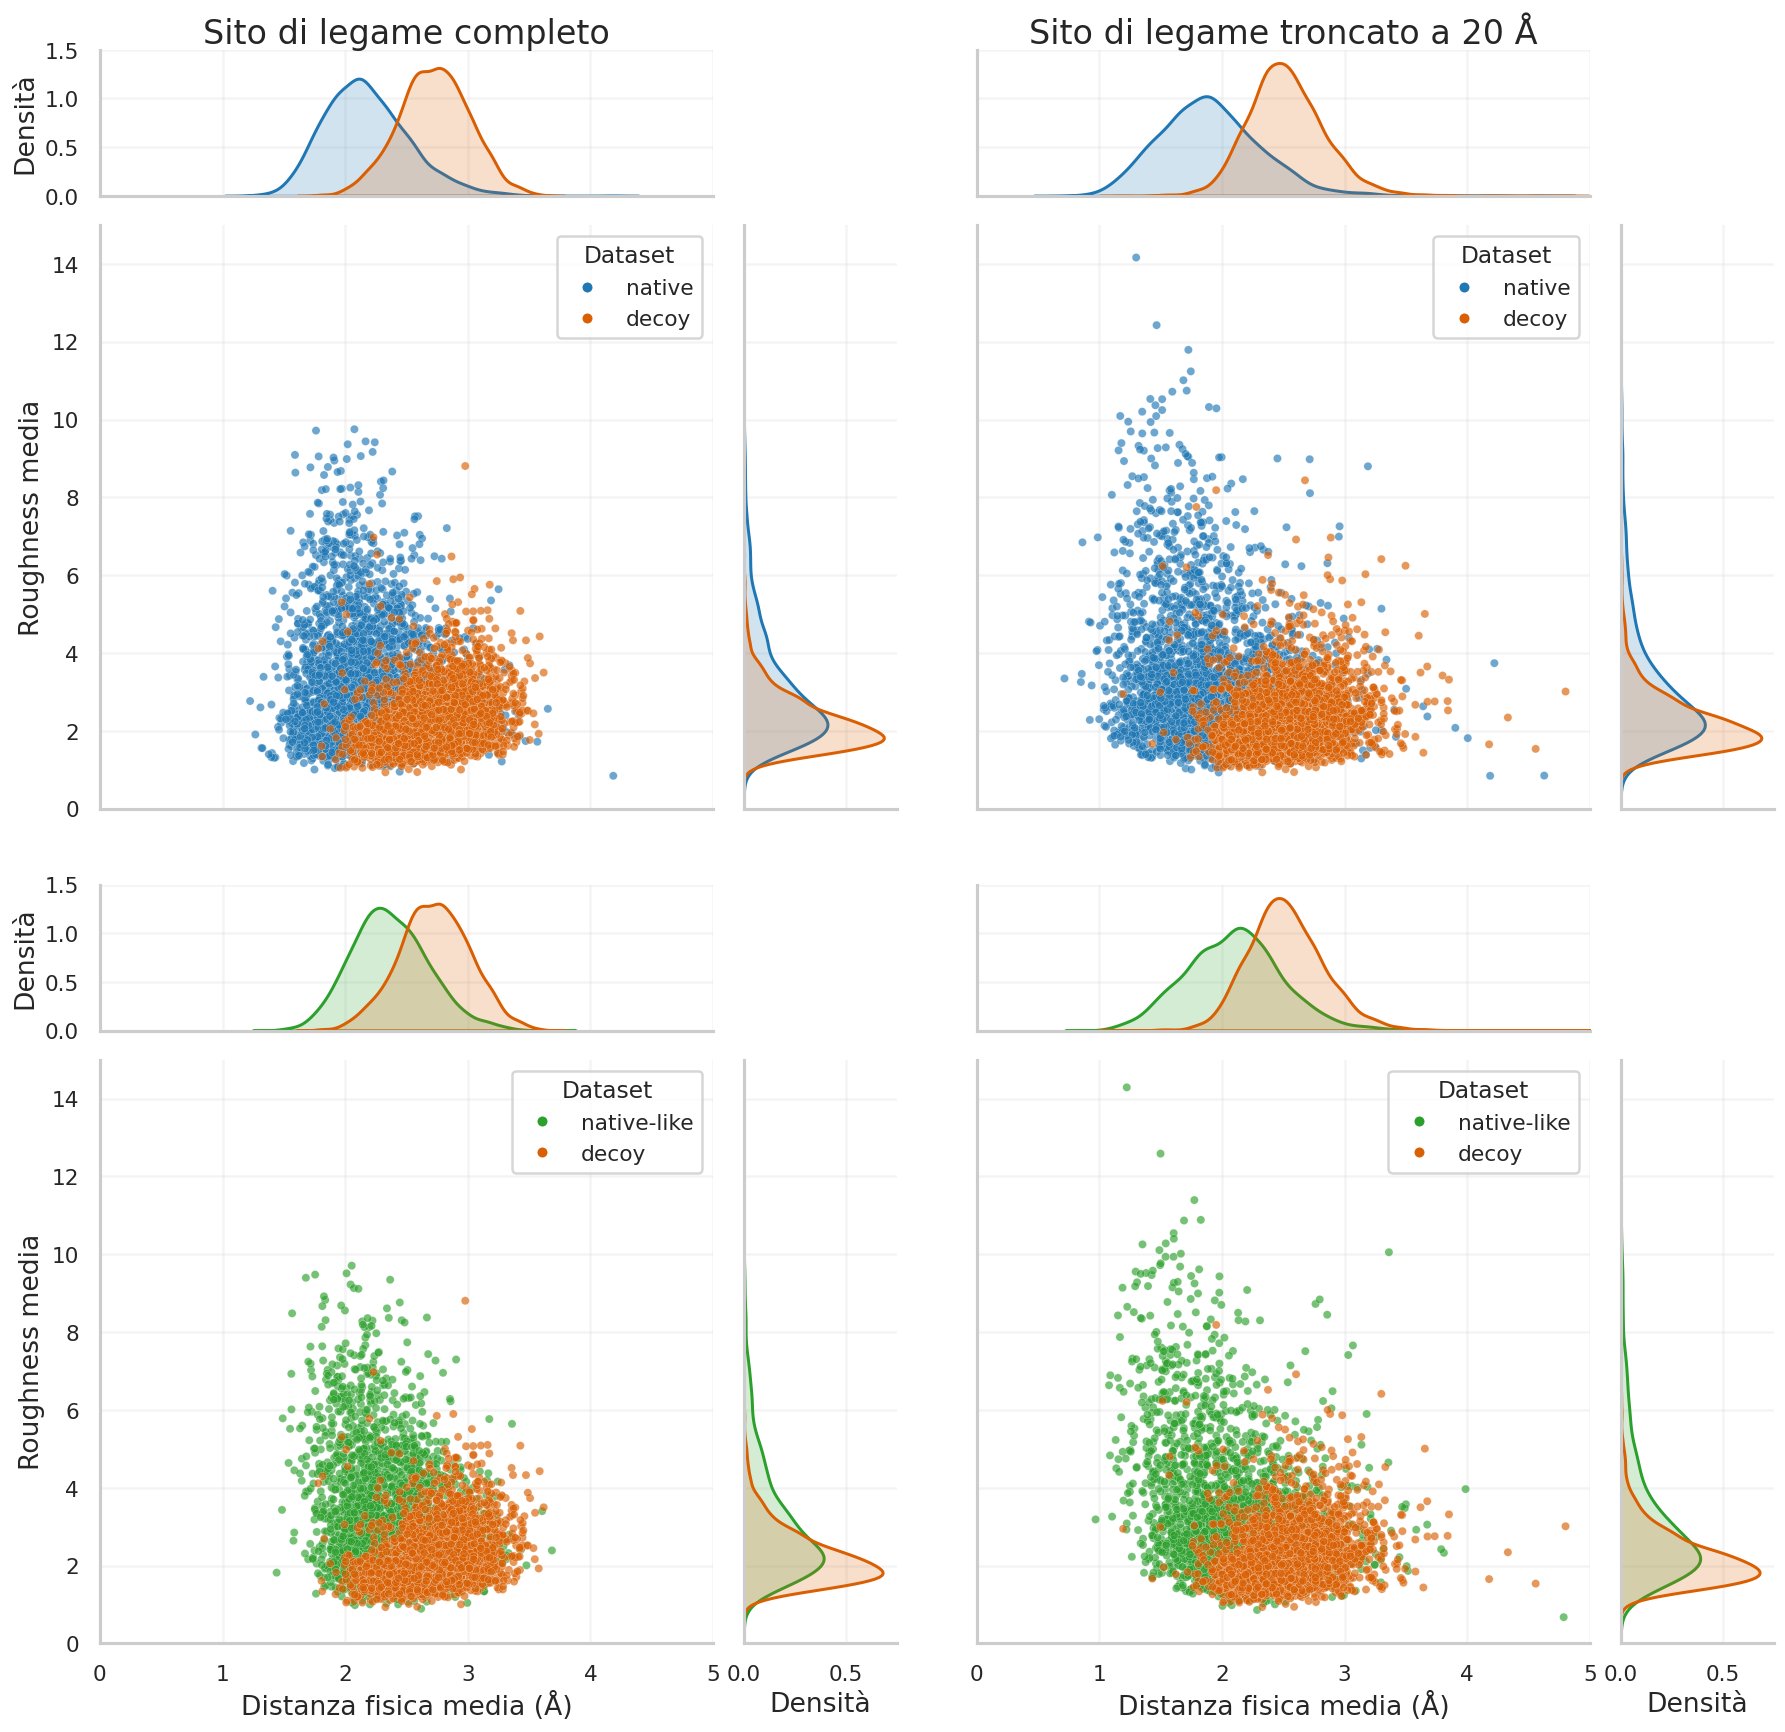

Punti global native: 3134
Punti global decoy: 3134
Punti filtrati native: 3123
Punti filtrati decoy: 3125
Punti global native-like: 2665
Punti global decoy: 2665
Punti filtrati native-like: 2655
Punti filtrati decoy: 2657
Separation global: AUC = 0.9115 +/- 0.0061 | accuracy = 0.848 +/- 0.0066 | n = 6268
Separation filtered: AUC = 0.9029 +/- 0.0086 | accuracy = 0.8419 +/- 0.0116 | n = 6248
Separation nativelike global: AUC = 0.8465 +/- 0.0095 | accuracy = 0.7771 +/- 0.0117 | n = 5330
Separation nativelike filtered: AUC = 0.8313 +/- 0.0054 | accuracy = 0.7611 +/- 0.0069 | n = 5312
Meglio separati: global
Physical mean global native: min / max = 1.2250244809207986 4.186349089671241
Physical mean global decoy: min / max = 1.7804382463298005 3.618791735978244
Physical mean filtered native: min / max = 0.7154839269135532 4.627309186836516
Physical mean filtered decoy: min / max = 1.1937064538488467 4.80123027771219
Physical mean native-like global: min / max = 1.4413814932280642 3.686182233

In [12]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

zernike_ring_cols = [f'zernike_ring{i}_mean' for i in range(1, 11)]
physical_ring_cols = [f'physical_ring{i}_mean' for i in range(1, 11)]
ring_mean_cols = [f'ring{i}_mean_A' for i in range(1, 11)]
roughness_ring_cols = [f'roughness_ring{i}' for i in range(1, 11)]


def summarize_by_complex(df, cols):
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[cols].mean()
    wide_frames = []
    for dataset_label in ['native', 'decoy']:
        dataset_frame = grouped[grouped['dataset_label'] == dataset_label].set_index('complex_name')[cols]
        dataset_frame = dataset_frame.rename(columns={col: f'{col}_{dataset_label}' for col in cols})
        wide_frames.append(dataset_frame)
    return pd.concat(wide_frames, axis=1)


def build_plot_df(df, positive_label='native', negative_label='decoy', use_rdf_roughness=False, radius_limit=20.0):
    grouped_cols = ['radius', 'roughness'] + physical_ring_cols + roughness_ring_cols
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[grouped_cols].mean()
    rows = []
    for dataset_label in [positive_label, negative_label]:
        dataset_df = grouped[grouped['dataset_label'] == dataset_label]
        for _, row in dataset_df.iterrows():
            radius = pd.to_numeric(pd.Series([row['radius']]), errors='coerce').iloc[0]
            if not np.isfinite(radius) or radius <= 0:
                continue

            if use_rdf_roughness:
                valid_rings = [rid for rid in range(1, N_RINGS + 1) if radius * rid / float(N_RINGS) <= radius_limit]
                if not valid_rings:
                    continue
            else:
                valid_rings = list(range(1, N_RINGS + 1))

            physical_values = []
            for rid in valid_rings:
                physical_col = f'physical_ring{rid}_mean'
                if physical_col not in row.index:
                    continue
                physical_value = pd.to_numeric(pd.Series([row[physical_col]]), errors='coerce').iloc[0]
                if np.isfinite(physical_value):
                    physical_values.append(float(physical_value))

            if not physical_values:
                continue

            # Use ring-wise roughness mean in both global and truncated settings.
            roughness_values = []
            for rid in valid_rings:
                roughness_col = f'roughness_ring{rid}'
                if roughness_col not in row.index:
                    continue
                roughness_value = pd.to_numeric(pd.Series([row[roughness_col]]), errors='coerce').iloc[0]
                if np.isfinite(roughness_value):
                    roughness_values.append(float(roughness_value))

            if not roughness_values:
                continue

            rows.append({
                'complex_name': row['complex_name'],
                'dataset_label': dataset_label,
                'physical_mean': float(np.mean(physical_values)),
                'roughness': float(np.mean(roughness_values)),
            })

    return pd.DataFrame(rows)


def _safe_kde(ax, values, orientation, color):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size < 2 or np.nanstd(values) == 0:
        if values.size == 1:
            if orientation == 'x':
                ax.axvline(values[0], color=color, linewidth=1.6, alpha=0.4)
            else:
                ax.axhline(values[0], color=color, linewidth=1.6, alpha=0.4)
        return
    if orientation == 'x':
        sns.kdeplot(x=values, ax=ax, color=color, linewidth=1.8, fill=True, alpha=0.20)
    else:
        sns.kdeplot(y=values, ax=ax, color=color, linewidth=1.8, fill=True, alpha=0.20)


def plot_joint_panel(fig, outer_spec, data, title, label_order, palette, *, show_title=False, hide_main_x=False, hide_marginal_right_y=False, hide_all_ticks_labels=False, hide_main_y=False, hide_marginal_top_y=False, hide_marginal_right_x=False, hide_marginal_top_x=False):
    inner = outer_spec.subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.08, wspace=0.08)
    ax_marg_x = fig.add_subplot(inner[0, 0])
    ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_marg_x)
    ax_marg_y = fig.add_subplot(inner[1, 1], sharey=ax_joint)
    ax_blank = fig.add_subplot(inner[0, 1])
    ax_blank.axis('off')

    sns.scatterplot(
        data=data,
        x='physical_mean',
        y='roughness',
        hue='dataset_label',
        hue_order=label_order,
        palette=palette,
        s=24,
        alpha=0.65,
        edgecolor='white',
        linewidth=0.2,
        ax=ax_joint,
        legend=False,
    )

    for dataset_label in label_order:
        color = palette[dataset_label]
        subset = data.loc[data['dataset_label'] == dataset_label]
        _safe_kde(ax_marg_x, subset['physical_mean'], 'x', color)
        _safe_kde(ax_marg_y, subset['roughness'], 'y', color)

    if show_title:
        ax_marg_x.set_title(title, fontsize=20, pad=3)
    else:
        ax_joint.set_title('')

    ax_joint.set_xlabel('Distanza fisica media (Å)')
    ax_joint.set_ylabel('Roughness media')
    ax_joint.set_xlim(0, 5)
    ax_joint.set_ylim(0, 15)
    ax_joint.grid(alpha=0.2)

    ax_marg_x.set_ylabel('Densità')
    ax_marg_y.set_xlabel('Densità')
    ax_marg_x.set_ylim(0, 1.5)
    ax_marg_y.set_xlim(0, 0.75)
    ax_marg_x.grid(alpha=0.2)
    ax_marg_y.grid(alpha=0.2)

    if hide_main_x:
        ax_joint.set_xlabel('')
        ax_joint.tick_params(axis='x', bottom=False, labelbottom=False)
    if hide_main_y:
        ax_joint.set_ylabel('')
        ax_joint.tick_params(axis='y', left=False, labelleft=False)
    if hide_marginal_right_y:
        ax_marg_y.set_ylabel('')
        ax_marg_y.tick_params(axis='y', left=False, labelleft=False)
    if hide_marginal_top_y:
        ax_marg_x.set_ylabel('')
        ax_marg_x.tick_params(axis='y', left=False, labelleft=False)
    if hide_marginal_right_x:
        ax_marg_y.set_xlabel('')
        ax_marg_y.tick_params(axis='x', bottom=False, labelbottom=False)
    if hide_marginal_top_x:
        ax_marg_x.set_xlabel('')
        ax_marg_x.tick_params(axis='x', bottom=False, labelbottom=False)

    if hide_all_ticks_labels:
        for axis in (ax_joint, ax_marg_x, ax_marg_y):
            axis.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)
            axis.set_xlabel('')
            axis.set_ylabel('')

    handles = [
        Line2D([0], [0], marker='o', linestyle='', markerfacecolor=color, markeredgecolor='white', markersize=7, label=label)
        for label, color in [(label, palette[label]) for label in label_order]
    ]
    ax_joint.legend(handles=handles, title='Dataset', loc='best')


def _grouped_oof_scores(clean_df, positive_label, negative_label, n_splits=5, random_state=42):
    if clean_df.empty or clean_df['dataset_label'].nunique() < 2:
        return None

    X = clean_df[['physical_mean', 'roughness']].to_numpy(dtype=float)
    y = (clean_df['dataset_label'] == negative_label).astype(int).to_numpy()
    groups = clean_df['complex_name'].astype(str).to_numpy()

    unique_groups = pd.Series(groups).nunique()
    if unique_groups < 2:
        return None

    splitter = StratifiedGroupKFold(n_splits=min(n_splits, int(unique_groups)), shuffle=True, random_state=random_state)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

    y_score = np.full(shape=y.shape, fill_value=np.nan, dtype=float)
    fold_auc = []
    fold_acc = []

    try:
        for train_idx, test_idx in splitter.split(X, y, groups=groups):
            model.fit(X[train_idx], y[train_idx])
            probs = model.predict_proba(X[test_idx])[:, 1]
            y_score[test_idx] = probs

            y_test = y[test_idx]
            if np.unique(y_test).size == 2:
                fold_auc.append(float(roc_auc_score(y_test, probs)))
            preds = (probs >= 0.5).astype(int)
            fold_acc.append(float(np.mean(preds == y_test)))
    except ValueError:
        return None

    finite_mask = np.isfinite(y_score)
    if finite_mask.sum() == 0:
        return None

    y_valid = y[finite_mask]
    score_valid = y_score[finite_mask]
    auc_oof = np.nan
    if np.unique(y_valid).size == 2:
        auc_oof = float(roc_auc_score(y_valid, score_valid))

    return {
        'y': y,
        'y_score': y_score,
        'auc_oof': auc_oof,
        'auc_std': float(np.std(fold_auc)) if fold_auc else np.nan,
        'auc_mean_folds': float(np.mean(fold_auc)) if fold_auc else np.nan,
        'accuracy_mean': float(np.mean(fold_acc)) if fold_acc else np.nan,
        'accuracy_std': float(np.std(fold_acc)) if fold_acc else np.nan,
    }


def compare_separation(df, label, positive_label='native', negative_label='decoy'):
    clean_df = df.dropna(subset=['complex_name', 'physical_mean', 'roughness', 'dataset_label']).copy()
    oof_result = _grouped_oof_scores(clean_df, positive_label=positive_label, negative_label=negative_label)
    if oof_result is None:
        return {
            'label': label,
            'n': int(clean_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    return {
        'label': label,
        'n': int(clean_df.shape[0]),
        'auc_mean': float(oof_result['auc_oof']),
        'auc_std': float(oof_result['auc_std']),
        'accuracy_mean': float(oof_result['accuracy_mean']),
        'accuracy_std': float(oof_result['accuracy_std']),
    }


plot_df_global = build_plot_df(tot_df, use_rdf_roughness=False)
plot_df_filtered = build_plot_df(tot_df, use_rdf_roughness=True, radius_limit=20.0)
plot_df_nativelike_global = build_plot_df(tot_nativelike_df, positive_label='nativelike', negative_label='decoy2', use_rdf_roughness=False)
plot_df_nativelike_filtered = build_plot_df(tot_nativelike_df, positive_label='nativelike', negative_label='decoy2', use_rdf_roughness=True, radius_limit=20.0)
plot_df_nativelike_global['dataset_label'] = plot_df_nativelike_global['dataset_label'].replace({'nativelike': 'native-like', 'decoy2': 'decoy'})
plot_df_nativelike_filtered['dataset_label'] = plot_df_nativelike_filtered['dataset_label'].replace({'nativelike': 'native-like', 'decoy2': 'decoy'})

separation_global = compare_separation(plot_df_global, 'global')
separation_filtered = compare_separation(plot_df_filtered, 'filtered')
separation_nativelike_global = compare_separation(plot_df_nativelike_global, 'nativelike_global', positive_label='native-like', negative_label='decoy')
separation_nativelike_filtered = compare_separation(plot_df_nativelike_filtered, 'nativelike_filtered', positive_label='native-like', negative_label='decoy')

fig = plt.figure(figsize=(18, 16))
outer = fig.add_gridspec(2, 2, wspace=0.1, hspace=0.1)
top_palette = {'native': '#1f77b4', 'decoy': '#d95f02'}
bottom_palette = {'native-like': '#2ca02c', 'decoy': '#d95f02'}

plot_joint_panel(
    fig,
    outer[0, 0],
    plot_df_global,
    'Sito di legame completo',
    ['native', 'decoy'],
    top_palette,
    show_title=True,
    hide_main_x=True,
    hide_marginal_right_y=True,
    hide_marginal_right_x=True,
    hide_marginal_top_x=True,
)
plot_joint_panel(
    fig,
    outer[0, 1],
    plot_df_filtered,
    'Sito di legame troncato a 20 Å',
    ['native', 'decoy'],
    top_palette,
    show_title=True,
    hide_all_ticks_labels=True,
)
plot_joint_panel(
    fig,
    outer[1, 0],
    plot_df_nativelike_global,
    'Sito di legame completo',
    ['native-like', 'decoy'],
    bottom_palette,
    show_title=False,
    hide_marginal_top_x=True,
    hide_marginal_right_y=True,
)
plot_joint_panel(
    fig,
    outer[1, 1],
    plot_df_nativelike_filtered,
    'Sito di legame troncato a 20 Å',
    ['native-like', 'decoy'],
    bottom_palette,
    show_title=False,
    hide_main_y=True,
    hide_marginal_top_x=True,
    hide_marginal_top_y=True,
    hide_marginal_right_y=True,
)

fig.subplots_adjust(top=0.94, wspace=0.06, hspace=0.08)
plt.savefig('presentation/scatter_physical_roughness.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Punti global native:', int((plot_df_global['dataset_label'] == 'native').sum()))
print('Punti global decoy:', int((plot_df_global['dataset_label'] == 'decoy').sum()))
print('Punti filtrati native:', int((plot_df_filtered['dataset_label'] == 'native').sum()))
print('Punti filtrati decoy:', int((plot_df_filtered['dataset_label'] == 'decoy').sum()))
print('Punti global native-like:', int((plot_df_nativelike_global['dataset_label'] == 'native-like').sum()))
print('Punti global decoy:', int((plot_df_nativelike_global['dataset_label'] == 'decoy').sum()))
print('Punti filtrati native-like:', int((plot_df_nativelike_filtered['dataset_label'] == 'native-like').sum()))
print('Punti filtrati decoy:', int((plot_df_nativelike_filtered['dataset_label'] == 'decoy').sum()))
print('Separation global: AUC =', round(separation_global['auc_mean'], 4), '+/-', round(separation_global['auc_std'], 4), '| accuracy =', round(separation_global['accuracy_mean'], 4), '+/-', round(separation_global['accuracy_std'], 4), '| n =', separation_global['n'])
print('Separation filtered: AUC =', round(separation_filtered['auc_mean'], 4), '+/-', round(separation_filtered['auc_std'], 4), '| accuracy =', round(separation_filtered['accuracy_mean'], 4), '+/-', round(separation_filtered['accuracy_std'], 4), '| n =', separation_filtered['n'])
print('Separation nativelike global: AUC =', round(separation_nativelike_global['auc_mean'], 4), '+/-', round(separation_nativelike_global['auc_std'], 4), '| accuracy =', round(separation_nativelike_global['accuracy_mean'], 4), '+/-', round(separation_nativelike_global['accuracy_std'], 4), '| n =', separation_nativelike_global['n'])
print('Separation nativelike filtered: AUC =', round(separation_nativelike_filtered['auc_mean'], 4), '+/-', round(separation_nativelike_filtered['auc_std'], 4), '| accuracy =', round(separation_nativelike_filtered['accuracy_mean'], 4), '+/-', round(separation_nativelike_filtered['accuracy_std'], 4), '| n =', separation_nativelike_filtered['n'])
print('Meglio separati:', 'filtered' if separation_filtered['auc_mean'] > separation_global['auc_mean'] else 'global')
print('Physical mean global native: min / max =', float(plot_df_global.loc[plot_df_global['dataset_label'] == 'native', 'physical_mean'].min()), float(plot_df_global.loc[plot_df_global['dataset_label'] == 'native', 'physical_mean'].max()))
print('Physical mean global decoy: min / max =', float(plot_df_global.loc[plot_df_global['dataset_label'] == 'decoy', 'physical_mean'].min()), float(plot_df_global.loc[plot_df_global['dataset_label'] == 'decoy', 'physical_mean'].max()))
print('Physical mean filtered native: min / max =', float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'native', 'physical_mean'].min()), float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'native', 'physical_mean'].max()))
print('Physical mean filtered decoy: min / max =', float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'decoy', 'physical_mean'].min()), float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'decoy', 'physical_mean'].max()))
print('Physical mean native-like global: min / max =', float(plot_df_nativelike_global.loc[plot_df_nativelike_global['dataset_label'] == 'native-like', 'physical_mean'].min()), float(plot_df_nativelike_global.loc[plot_df_nativelike_global['dataset_label'] == 'native-like', 'physical_mean'].max()))
print('Physical mean decoy global: min / max =', float(plot_df_nativelike_global.loc[plot_df_nativelike_global['dataset_label'] == 'decoy', 'physical_mean'].min()), float(plot_df_nativelike_global.loc[plot_df_nativelike_global['dataset_label'] == 'decoy', 'physical_mean'].max()))

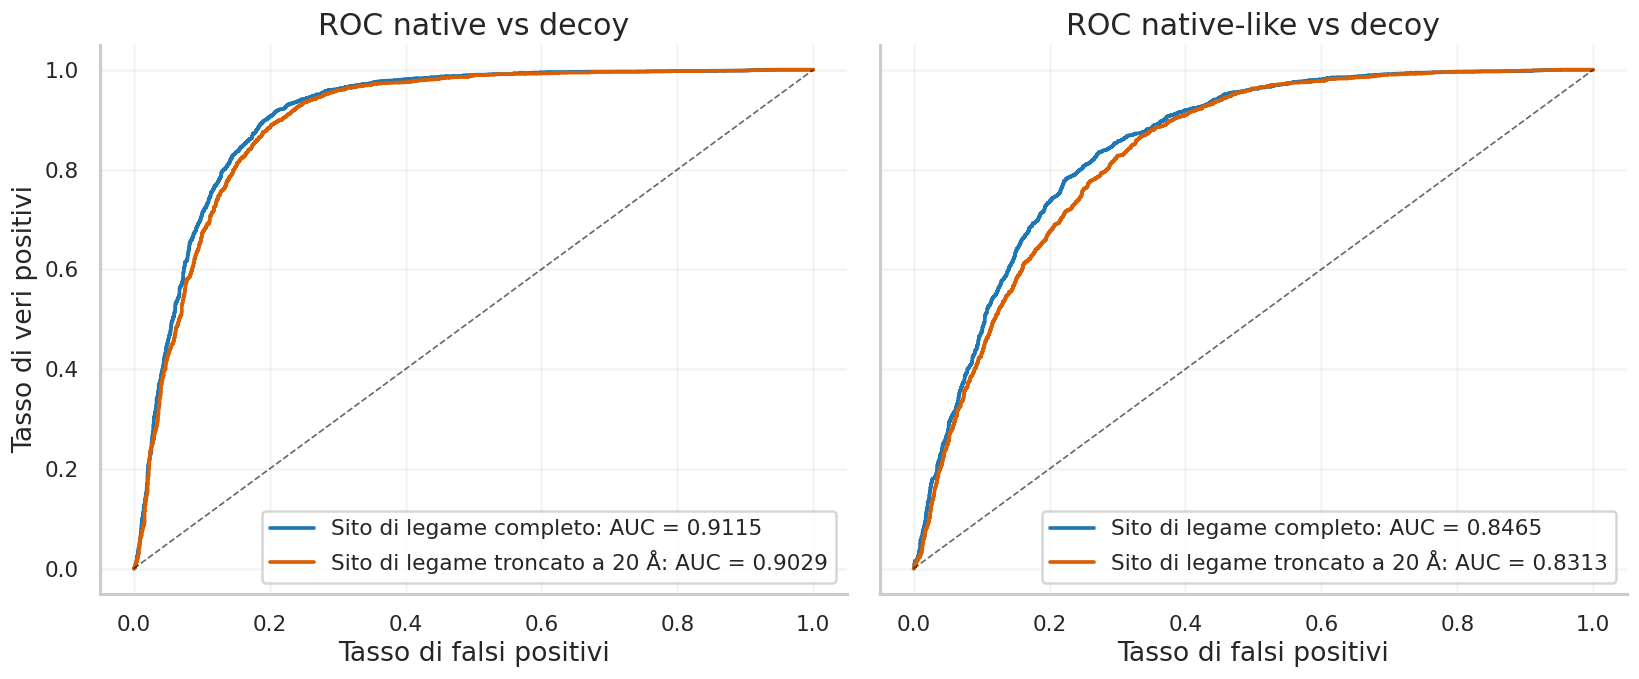

AUC ROC completo = 0.9115210860240058
AUC ROC filtrato 20 Å = 0.9028983925712455
AUC ROC nativelike completo = 0.8464637490363933
AUC ROC nativelike filtrato 20 Å = 0.8312596438927269


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score


def plot_roc_curves(ax, df, color, label, positive_label='native', negative_label='decoy'):
    clean_df = df.dropna(subset=['complex_name', 'physical_mean', 'roughness', 'dataset_label']).copy()
    oof_result = _grouped_oof_scores(clean_df, positive_label=positive_label, negative_label=negative_label)
    if oof_result is None:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Tasso di falsi positivi')
        ax.set_ylabel('Tasso di veri positivi')
        ax.grid(alpha=0.2)
        return np.nan

    y = oof_result['y']
    y_score = oof_result['y_score']
    finite_mask = np.isfinite(y_score)
    y = y[finite_mask]
    y_score = y_score[finite_mask]
    if y.size == 0 or np.unique(y).size < 2:
        ax.text(0.5, 0.5, 'Not enough class variability', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Tasso di falsi positivi')
        ax.set_ylabel('Tasso di veri positivi')
        ax.grid(alpha=0.2)
        return np.nan

    fpr, tpr, _ = roc_curve(y, y_score)
    auc_value = roc_auc_score(y, y_score)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{label}: AUC = {auc_value:.4f}')
    return auc_value


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

auc_global_roc = plot_roc_curves(axes[0], plot_df_global, '#1f77b4', 'Sito di legame completo', positive_label='native', negative_label='decoy')
auc_filtered_roc = plot_roc_curves(axes[0], plot_df_filtered, '#d95f02', 'Sito di legame troncato a 20 Å', positive_label='native', negative_label='decoy')
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.0, alpha=0.6)
axes[0].set_title('ROC native vs decoy')
axes[0].set_xlabel('Tasso di falsi positivi')
axes[0].set_ylabel('Tasso di veri positivi')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='lower right')

auc_nativelike_global_roc = plot_roc_curves(axes[1], plot_df_nativelike_global, '#1f77b4', 'Sito di legame completo', positive_label='native-like', negative_label='decoy')
auc_nativelike_filtered_roc = plot_roc_curves(axes[1], plot_df_nativelike_filtered, '#d95f02', 'Sito di legame troncato a 20 Å', positive_label='native-like', negative_label='decoy')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.0, alpha=0.6)
axes[1].set_title('ROC native-like vs decoy')
axes[1].set_xlabel('Tasso di falsi positivi')
axes[1].grid(alpha=0.2)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('AUC ROC completo =', float(auc_global_roc))
print('AUC ROC filtrato 20 Å =', float(auc_filtered_roc))
print('AUC ROC nativelike completo =', float(auc_nativelike_global_roc))
print('AUC ROC nativelike filtrato 20 Å =', float(auc_nativelike_filtered_roc))

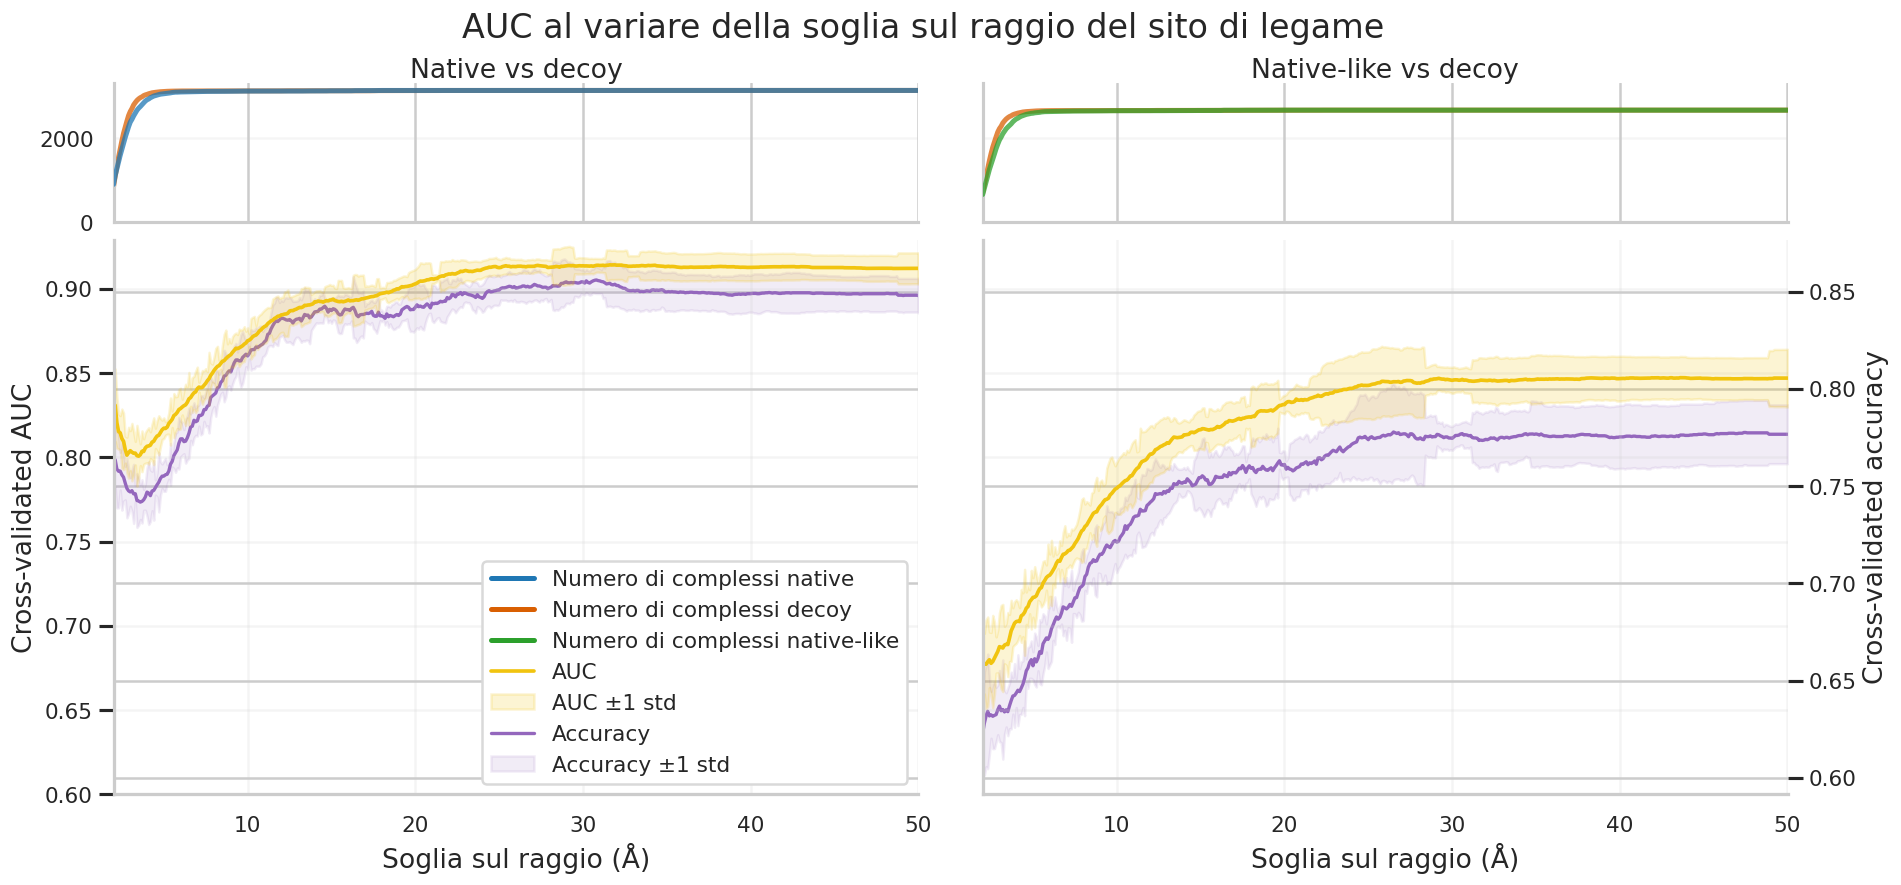

Soglia migliore global: 31.600000000000026
AUC migliore global: 0.9141819921139613
Accuracy alla soglia migliore global: 0.8542094127387525
Std accuracy alla soglia migliore global: 0.011674227505638603
Numero di punti alla soglia migliore global: 6256
Soglia migliore nativelike: 43.60000000000004
AUC migliore nativelike: 0.847267445473187
Accuracy alla soglia migliore nativelike: 0.7762133085226235
Std accuracy alla soglia migliore nativelike: 0.01592738473996327
Numero di punti alla soglia migliore nativelike: 5322
Ultima soglia testata: 50.00000000000004
AUC allultima soglia global: 0.9121137208824954
Accuracy allultima soglia global: 0.847928106459736
Std accuracy allultima soglia global: 0.008839869321012633
AUC allultima soglia nativelike: 0.8469922420605847
Accuracy allultima soglia nativelike: 0.776619830318641
Std accuracy allultima soglia nativelike: 0.015134097921697795


In [14]:
threshold_step = 0.1
max_threshold = 50
thresholds = np.arange(2.0, max_threshold + 1e-9, threshold_step)

threshold_base_df = tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['radius'] + physical_ring_cols + roughness_ring_cols].mean()
threshold_base_nativelike_df = tot_nativelike_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['radius'] + physical_ring_cols + roughness_ring_cols].mean()


def build_threshold_plot_df(grouped_df, radius_limit):
    radius = grouped_df['radius'].to_numpy(dtype=float)
    ring_ids = np.arange(1, N_RINGS + 1, dtype=float)
    valid_mask = (ring_ids[None, :] * radius[:, None] / float(N_RINGS)) <= float(radius_limit)

    physical_values = grouped_df[physical_ring_cols].to_numpy(dtype=float)
    roughness_values = grouped_df[roughness_ring_cols].to_numpy(dtype=float)

    physical_masked = np.where(valid_mask, physical_values, np.nan)
    roughness_masked = np.where(valid_mask, roughness_values, np.nan)

    physical_count = np.sum(np.isfinite(physical_masked), axis=1)
    roughness_count = np.sum(np.isfinite(roughness_masked), axis=1)
    physical_sum = np.nansum(physical_masked, axis=1)
    roughness_sum = np.nansum(roughness_masked, axis=1)

    physical_mean = np.divide(
        physical_sum,
        physical_count,
        out=np.full(physical_sum.shape, np.nan, dtype=float),
        where=physical_count > 0,
    )
    roughness_mean = np.divide(
        roughness_sum,
        roughness_count,
        out=np.full(roughness_sum.shape, np.nan, dtype=float),
        where=roughness_count > 0,
    )

    result = grouped_df[['complex_name', 'dataset_label']].copy()
    result['radius'] = radius
    result['physical_mean'] = physical_mean
    result['roughness'] = roughness_mean
    return result.dropna(subset=['physical_mean', 'roughness']).copy()


def build_threshold_count_df(grouped_df, radius_limit):
    radius = pd.to_numeric(grouped_df['radius'], errors='coerce')
    valid_mask = radius < float(radius_limit) * 10.0
    count_df = (
        grouped_df.loc[valid_mask, ['complex_name', 'dataset_label']]
        .groupby('dataset_label', as_index=False)
        .size()
        .rename(columns={'size': 'n_complexes'})
    )
    count_df['threshold_A'] = float(radius_limit)
    return count_df[['threshold_A', 'dataset_label', 'n_complexes']]


def build_threshold_curves(grouped_df, positive_label, negative_label):
    auc_threshold_rows = []
    count_threshold_frames = []
    for threshold in thresholds:
        filtered_df = build_threshold_plot_df(grouped_df, float(threshold))
        separation = compare_separation(
            filtered_df,
            f'filtered_{threshold:.1f}',
            positive_label=positive_label,
            negative_label=negative_label,
        )
        auc_threshold_rows.append({
            'threshold_A': float(threshold),
            'auc_mean': separation['auc_mean'],
            'auc_std': separation['auc_std'],
            'accuracy_mean': separation['accuracy_mean'],
            'accuracy_std': separation['accuracy_std'],
            'n': separation['n'],
        })
        count_threshold_frames.append(build_threshold_count_df(grouped_df, float(threshold)))

    auc_threshold_df = pd.DataFrame(auc_threshold_rows)
    count_threshold_df = pd.concat(count_threshold_frames, ignore_index=True)
    count_threshold_pivot = (
        count_threshold_df.pivot(index='threshold_A', columns='dataset_label', values='n_complexes')
        .reindex(thresholds)
        .fillna(0.0)
    )
    return auc_threshold_df, count_threshold_pivot


def plot_threshold_panel(
    ax_main,
    ax_top,
    auc_threshold_df,
    count_threshold_pivot,
    title,
    colors,
    positive_label,
    negative_label,
    *,
    show_left_ylabel=False,
    show_right_ylabel=False,
    hide_main_y=False,
    accuracy_ylim=None,
    hide_accuracy_ticks=False,
    show_legend=True,
    legend_handles=None,
):
    x_values = auc_threshold_df['threshold_A'].to_numpy(dtype=float)
    auc_values = auc_threshold_df['auc_mean'].to_numpy(dtype=float)
    auc_std = auc_threshold_df['auc_std'].to_numpy(dtype=float)
    accuracy_values = auc_threshold_df['accuracy_mean'].to_numpy(dtype=float)
    accuracy_std = auc_threshold_df['accuracy_std'].to_numpy(dtype=float)

    ax_main.plot(x_values, auc_values, color=colors['auc'], linewidth=2.2, label='AUC')
    ax_main.fill_between(
        x_values,
        auc_values - auc_std,
        auc_values + auc_std,
        color=colors['auc'],
        alpha=0.18,
        label='AUC ±1 std',
    )
    ax_accuracy = ax_main.twinx()
    ax_main.set_zorder(2)
    ax_accuracy.set_zorder(1)
    ax_main.patch.set_alpha(0)
    ax_accuracy.patch.set_alpha(0)
    ax_accuracy.plot(x_values, accuracy_values, color=colors['accuracy'], linewidth=2.0, label='Accuracy')
    ax_accuracy.fill_between(
        x_values,
        accuracy_values - accuracy_std,
        accuracy_values + accuracy_std,
        color=colors['accuracy'],
        alpha=0.12,
        label='Accuracy ±1 std',
    )
    ax_accuracy.set_ylabel('Cross-validated accuracy')
    if accuracy_ylim is not None:
        ax_accuracy.set_ylim(*accuracy_ylim)
    if hide_accuracy_ticks:
        ax_accuracy.tick_params(axis='y', right=False, labelright=False)

    positive_counts = count_threshold_pivot[positive_label].to_numpy(dtype=float) if positive_label in count_threshold_pivot.columns else np.zeros_like(x_values)
    negative_counts = count_threshold_pivot[negative_label].to_numpy(dtype=float) if negative_label in count_threshold_pivot.columns else np.zeros_like(x_values)

    ax_top.plot(x_values, positive_counts, color=colors['positive'], linewidth=3.0, alpha=0.75, label=f'Numero di complessi {positive_label}', zorder=3)
    ax_top.plot(x_values, negative_counts, color=colors['negative'], linewidth=3.0, alpha=0.75, label=f'Numero di complessi {negative_label}', zorder=2)

    if title:
        ax_top.set_title(title, fontsize=16, pad=3)
    else:
        ax_top.set_title('')
    ax_main.set_xlabel('Soglia sul raggio (Å)')
    if show_left_ylabel:
        ax_main.set_ylabel('Cross-validated AUC')
    else:
        ax_main.set_ylabel('')
    if hide_main_y:
        ax_main.tick_params(axis='y', left=False, labelleft=False)
    if show_right_ylabel:
        ax_accuracy.set_ylabel('Cross-validated accuracy')
    else:
        ax_accuracy.set_ylabel('')

    ax_main.grid(alpha=0.2)
    ax_top.grid(axis='y', alpha=0.18)
    ax_main.set_xlim(thresholds.min(), thresholds.max())
    ax_main.set_ylim(0.6, max(float(np.nanmax(auc_values + auc_std)) if auc_values.size else 0.0, float(np.nanmax(accuracy_values + accuracy_std)) if accuracy_values.size else 0.0) * 1.05 + 0.02)
    ax_top.set_xlim(thresholds.min(), thresholds.max())
    ax_top.set_ylim(0, 3300)
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.tick_params(axis='y', pad=3)

    best_idx = auc_threshold_df['auc_mean'].idxmax()
    best_row = auc_threshold_df.loc[best_idx]

    if show_legend:
        if legend_handles is None:
            legend_handles = [
                Line2D([0], [0], marker='o', linestyle='', markerfacecolor=color, markeredgecolor='white', markersize=7, label=label)
                for label, color in [(label, colors['positive']) if label == positive_label else (label, colors['negative']) for label in [positive_label, negative_label]]
            ]
            legend_handles += [
                Line2D([0], [0], color=colors['auc'], linewidth=2.2, label='AUC'),
                Patch(facecolor=colors['auc'], edgecolor=colors['auc'], alpha=0.18, label='AUC ±1 std'),
                Line2D([0], [0], color=colors['accuracy'], linewidth=2.0, label='Accuracy'),
                Patch(facecolor=colors['accuracy'], edgecolor=colors['accuracy'], alpha=0.12, label='Accuracy ±1 std'),
            ]
        legend = ax_main.legend(handles=legend_handles, loc='lower right', frameon=True, framealpha=1.0, facecolor='white', edgecolor='0.85')
        legend.set_zorder(100)

    return best_row


auc_threshold_df_global, count_threshold_pivot_global = build_threshold_curves(threshold_base_df, 'native', 'decoy')
auc_threshold_df_nativelike, count_threshold_pivot_nativelike = build_threshold_curves(threshold_base_nativelike_df, 'nativelike', 'decoy2')
accuracy_values_global = auc_threshold_df_global['accuracy_mean'].to_numpy(dtype=float)
accuracy_values_nativelike = auc_threshold_df_nativelike['accuracy_mean'].to_numpy(dtype=float)
accuracy_std_global = auc_threshold_df_global['accuracy_std'].to_numpy(dtype=float)
accuracy_std_nativelike = auc_threshold_df_nativelike['accuracy_std'].to_numpy(dtype=float)
accuracy_ylim = (
    float(min(np.nanmin(accuracy_values_global - accuracy_std_global), np.nanmin(accuracy_values_nativelike - accuracy_std_nativelike))) - 0.01,
    float(max(np.nanmax(accuracy_values_global + accuracy_std_global), np.nanmax(accuracy_values_nativelike + accuracy_std_nativelike))) + 0.01,
)

fig = plt.figure(figsize=(18, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 4], wspace=0.08, hspace=0.05)

ax_top_global = fig.add_subplot(gs[0, 0])
ax_main_global = fig.add_subplot(gs[1, 0], sharey=None)
ax_top_nativelike = fig.add_subplot(gs[0, 1], sharey=ax_top_global)
ax_main_nativelike = fig.add_subplot(gs[1, 1], sharey=ax_main_global)

colors_global = {'positive': '#1f77b4', 'negative': '#d95f02', 'auc': '#f1c40f', 'accuracy': '#9467bd'}
colors_nativelike = {'positive': '#2ca02c', 'negative': '#d95f02', 'auc': '#f1c40f', 'accuracy': '#9467bd'}

legend_handles_global = [
    Line2D([0], [0], color=colors_global['positive'], linewidth=3.0, label='Numero di complessi native'),
    Line2D([0], [0], color=colors_global['negative'], linewidth=3.0, label='Numero di complessi decoy'),
    Line2D([0], [0], color=colors_nativelike['positive'], linewidth=3.0, label='Numero di complessi native-like'),
    Line2D([0], [0], color=colors_global['auc'], linewidth=2.2, label='AUC'),
    Patch(facecolor=colors_global['auc'], edgecolor=colors_global['auc'], alpha=0.18, label='AUC ±1 std'),
    Line2D([0], [0], color=colors_global['accuracy'], linewidth=2.0, label='Accuracy'),
    Patch(facecolor=colors_global['accuracy'], edgecolor=colors_global['accuracy'], alpha=0.12, label='Accuracy ±1 std'),
]

best_row_global = plot_threshold_panel(
    ax_main_global,
    ax_top_global,
    auc_threshold_df_global,
    count_threshold_pivot_global,
    'Native vs decoy',
    colors_global,
    'native',
    'decoy',
    show_left_ylabel=True,
    accuracy_ylim=accuracy_ylim,
    hide_accuracy_ticks=True,
    legend_handles=legend_handles_global,
)
best_row_nativelike = plot_threshold_panel(
    ax_main_nativelike,
    ax_top_nativelike,
    auc_threshold_df_nativelike,
    count_threshold_pivot_nativelike,
    'Native-like vs decoy',
    colors_nativelike,
    'nativelike',
    'decoy2',
    show_right_ylabel=True,
    accuracy_ylim=accuracy_ylim,
    show_legend=False,
)

fig.suptitle('AUC al variare della soglia sul raggio del sito di legame', fontsize=20, y=0.98)
ax_top_global.set_xlabel('')
ax_top_nativelike.set_xlabel('')
ax_top_nativelike.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)
ax_main_nativelike.tick_params(axis='y', left=False, labelleft=False)
ax_top_nativelike.tick_params(axis='y', pad=3)

fig.subplots_adjust(top=0.90, wspace=0.06, hspace=0.08)
plt.savefig('presentation/auc_threshold_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Soglia migliore global:', float(best_row_global['threshold_A']))
print('AUC migliore global:', float(best_row_global['auc_mean']))
print('Accuracy alla soglia migliore global:', float(best_row_global['accuracy_mean']))
print('Std accuracy alla soglia migliore global:', float(best_row_global['accuracy_std']))
print('Numero di punti alla soglia migliore global:', int(best_row_global['n']))
print('Soglia migliore nativelike:', float(best_row_nativelike['threshold_A']))
print('AUC migliore nativelike:', float(best_row_nativelike['auc_mean']))
print('Accuracy alla soglia migliore nativelike:', float(best_row_nativelike['accuracy_mean']))
print('Std accuracy alla soglia migliore nativelike:', float(best_row_nativelike['accuracy_std']))
print('Numero di punti alla soglia migliore nativelike:', int(best_row_nativelike['n']))
print('Ultima soglia testata:', float(auc_threshold_df_global['threshold_A'].iloc[-1]))
print('AUC all' + 'ultima soglia global:', float(auc_threshold_df_global['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia global:', float(auc_threshold_df_global['accuracy_mean'].iloc[-1]))
print('Std accuracy all' + 'ultima soglia global:', float(auc_threshold_df_global['accuracy_std'].iloc[-1]))
print('AUC all' + 'ultima soglia nativelike:', float(auc_threshold_df_nativelike['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia nativelike:', float(auc_threshold_df_nativelike['accuracy_mean'].iloc[-1]))
print('Std accuracy all' + 'ultima soglia nativelike:', float(auc_threshold_df_nativelike['accuracy_std'].iloc[-1]))